# Domain-Adaptive Pretraining (DAPT) for Turkish BERT

This project investigates **domain-adaptive pretraining (DAPT)** for Turkish using a masked language modeling (MLM) objective.
Starting from the pretrained **dbmdz/bert-base-turkish-cased** model, we further pretrain on a large, domain-specific Turkish
corpus and evaluate the impact on both **in-domain performance** and **general-domain robustness**.

The experimental pipeline includes:
- A reproducible data preprocessing and packing strategy
- Controlled smoke and sweep experiments for configuration selection
- A full-scale final DAPT run
- Comprehensive evaluation on a held-out test set and a Wikipedia benchmark to analyze catastrophic forgetting

The results demonstrate consistent gains on the target domain while maintaining acceptable general-domain performance.

In [1]:
# Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip -q install datasets transformers scikit-learn tqdm torch nltk matplotlib dataclasses

In [3]:
# Standard library
import json
import re
import math
import time
import random
import shutil
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict
import unicodedata

# Third-party
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# PyTorch
import torch
from torch.utils.data import DataLoader

# Hugging Face Datasets
from datasets import Dataset, DatasetDict, load_from_disk

# Hugging Face Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    PreTrainedTokenizer,
    DataCollatorForLanguageModeling,
    TrainingArguments,
    Trainer,
    TrainerCallback,
)
from transformers.trainer_pt_utils import get_parameter_names
from transformers.pytorch_utils import ALL_LAYERNORM_LAYERS

import json, time
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from transformers import Trainer, TrainingArguments, TrainerCallback, AutoModelForMaskedLM
from transformers.trainer_pt_utils import get_parameter_names
from transformers.pytorch_utils import ALL_LAYERNORM_LAYERS

from datasets import load_dataset
from torch.utils.data import DataLoader
from transformers import DataCollatorForLanguageModeling

# Warnings
warnings.filterwarnings("ignore")

## Environment and Reproducibility

All experiments are executed using a fixed random seed to ensure reproducibility.
Training is performed with GPU acceleration when available, using mixed precision (FP16) to improve efficiency.
The same tokenizer and base model configuration are reused across all stages to guarantee consistent comparisons.

In [4]:
@dataclass
class CFG:
    data_path: str = "full_data_750.json"
    model_name: str = "dbmdz/bert-base-turkish-cased"
    max_len: int = 512
    mlm_prob: float = 0.15

    epochs: int = 3
    lr: float = 3e-5
    wd: float = 0.01
    warmup: float = 0.1
    train_bs: int = 8
    eval_bs: int = 4
    grad_accum: int = 4

    seed: int = 42

    mode: str = "smoke"     # smoke | sweep | final
    run_name: str = "main"
    max_steps: int | None = None

    save_artifacts: bool = True
    optim: str = "adamw"

    train_subset: int | None = 4000
    eval_subset: int | None = 500

    bf16=True


cfg = CFG()

In [5]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)

ROOT_RUN = Path("./runs") / time.strftime("%Y%m%d-%H%M%S")
ROOT_RUN.mkdir(parents=True, exist_ok=True)

def make_run_dir(stage: str) -> Path:
    d = ROOT_RUN / f"{stage}_{cfg.run_name}"
    d.mkdir(parents=True, exist_ok=True)
    (d / "cfg.json").write_text(
        json.dumps(cfg.__dict__, indent=2),
        encoding="utf-8"
    )
    return d

In [6]:
# Util Functions -> Using for all notebook

def fresh_model():
    return AutoModelForMaskedLM.from_pretrained(cfg.model_name).to(device)

def dump_json(path: Path, obj):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, indent=2), encoding="utf-8")

def maybe_subset(ds, n):
    if n is None:
        return ds
    return ds.select(range(min(n, len(ds))))

def run_dapt(
    stage_name: str,
    lm_train,
    lm_test,
    data_collator,
    compute_metrics,
    preprocess_logits_for_metrics,
    callbacks=None,
):
    seed_everything(cfg.seed)

    RUN_DIR = make_run_dir(stage_name)
    CKPT_DIR = RUN_DIR / "dapt_ckpts"
    CKPT_DIR.mkdir(parents=True, exist_ok=True)

    model = fresh_model()

    lm_train_run = maybe_subset(lm_train, cfg.train_subset)
    lm_test_run  = maybe_subset(lm_test,  cfg.eval_subset)

    trainer = Trainer(
        model=model,
        args=make_train_args(cfg, CKPT_DIR),
        train_dataset=lm_train_run,
        eval_dataset=lm_test_run,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        preprocess_logits_for_metrics=preprocess_logits_for_metrics,
        callbacks=(callbacks or []),
    )

    print(f"[{stage_name}] training started")
    trainer.train()

    eval_results = trainer.evaluate()

    dump_json(RUN_DIR / "eval_results.json", eval_results)
    dump_json(RUN_DIR / "history.json", trainer.state.log_history)

    summary = {
        "timestamp": datetime.now().isoformat(),
        "stage": stage_name,
        "mode": cfg.mode,
        "global_step": int(trainer.state.global_step),
        "eval_loss": float(eval_results["eval_loss"]),
        "eval_accuracy": float(eval_results.get("eval_accuracy", float("nan"))),
    }
    dump_json(RUN_DIR / "summary.json", summary)

    if cfg.mode == "final" and cfg.save_artifacts:
      FINAL_MODEL_DIR = RUN_DIR / "final_model"
      trainer.save_model(str(FINAL_MODEL_DIR))
      tokenizer.save_pretrained(str(FINAL_MODEL_DIR))

    return RUN_DIR, eval_results, trainer

def preprocess_logits_for_metrics(logits, labels):
    if isinstance(logits, tuple):
        logits = logits[0]
    return logits.argmax(dim=-1)

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    mask = labels != -100
    if mask.sum() == 0:
        return {"accuracy": 0.0}
    correct = (preds[mask] == labels[mask]).mean()
    return {"accuracy": float(correct)}

def eval_mlm_on_dataset(
    model_path: str,
    dataset,
    tokenizer,
    mlm_prob: float,
    batch_size: int = 8,
    topk: int = 5,
    device: str | None = None,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    model = AutoModelForMaskedLM.from_pretrained(model_path).to(device)
    model.eval()

    collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=True,
        mlm_probability=mlm_prob,
    )

    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collator,
    )

    loss_sum, steps = 0.0, 0
    masked_total = 0
    top1_ok = 0
    topk_ok = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Eval MLM ({model_path})"):
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)

            loss_sum += out.loss.item()
            steps += 1

            logits = out.logits
            labels = batch["labels"]
            mask = labels != -100
            if not mask.any():
                continue

            top_preds = logits.topk(topk, dim=-1).indices
            pred1 = top_preds[..., 0]

            y = labels[mask]
            p1 = pred1[mask]
            pk = top_preds[mask]

            masked_total += y.numel()
            top1_ok += (p1 == y).sum().item()
            topk_ok += (pk == y.unsqueeze(-1)).any(dim=-1).sum().item()

    avg_loss = loss_sum / max(1, steps)
    ppl = math.exp(avg_loss)
    top1 = top1_ok / max(1, masked_total)
    topk_acc = topk_ok / max(1, masked_total)

    del model
    torch.cuda.empty_cache()

    return {
        "avg_loss": float(avg_loss),
        "perplexity": float(ppl),
        "top1_acc": float(top1),
        f"top{topk}_acc": float(topk_acc),
        "masked_tokens": int(masked_total),
        "steps": int(steps),
      }

## Data Preparation and Token Packing
Raw documents are cleaned and segmented into sentences using rule-based filtering.
Sentences are then packed into fixed-length token blocks to maximize sequence utilization.


In [7]:
DRIVE_DATA_PATH = Path("/content/drive/MyDrive") / cfg.data_path
LOCAL_DATA_DIR  = Path("/content/data")
LOCAL_DATA_PATH = LOCAL_DATA_DIR / cfg.data_path
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

if not LOCAL_DATA_PATH.exists():
    print(f"Copying from Drive: {cfg.data_path}")
    shutil.copy(DRIVE_DATA_PATH, LOCAL_DATA_PATH)
else:
    print("Already exist")

Already exist


In [8]:
with LOCAL_DATA_PATH.open("r", encoding="utf-8") as f:
    records = json.load(f)

ds = Dataset.from_list(records).train_test_split(test_size=0.05, seed=cfg.seed)

train_docs = ds["train"]["content"]
test_docs  = ds["test"]["content"]

train_urls = ds["train"]["url"]
test_urls  = ds["test"]["url"]

print(f"Train documents: {len(train_docs)}")
print(f"Test documents: {len(test_docs)}")
print("Using data:", cfg.data_path)

Train documents: 326589
Test documents: 17189
Using data: full_data_750.json


### Sentence Segmentation and Cleaning

Documents are normalized and segmented into sentences.
Invalid or low-quality sentences are filtered using heuristic rules
based on length, character composition, and token count.

This step ensures cleaner input for downstream token packing.

In [9]:
MIN_SENT_LEN = 15
MAX_SENT_LEN = 512

def preprocess_text(text: str) -> str:
    if not text or not text.strip():
        return ""
    text = re.sub(r'(\d+)([a-zA-ZçğıöşüÇĞİÖŞÜ])', r'\1 \2', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\n+', ' ', text)
    text = text.replace('\xa0', ' ').replace('\u200b', '').replace('\ufeff', '')
    text = text.replace('–', '-').replace('—', '-').replace('…', '...')
    text = re.sub(r'([a-zçğıöşü])([A-ZÇĞİÖŞÜ][a-zçğıöşü])', r'\1. \2', text)
    return text.strip()

def is_valid_sentence(sent: str) -> bool:
    if len(sent) < MIN_SENT_LEN or len(sent) > MAX_SENT_LEN:
        return False

    if not any(c.isalpha() for c in sent):
        return False

    if len(sent.split()) < 2:
        return False

    return True

print(f"Preprocessing configured (MIN: {MIN_SENT_LEN}, MAX: {MAX_SENT_LEN})")

Preprocessing configured (MIN: 15, MAX: 512)


In [10]:
import nltk
from nltk.tokenize import sent_tokenize

nltk.download('punkt')

print("NLTK sentence tokenizer loaded")

NLTK sentence tokenizer loaded


In [11]:
def process_documents(docs: list) -> list:
    all_sents = []

    for text in tqdm(docs, desc="Processing"):
        clean_text = preprocess_text(text)
        if not clean_text:
            all_sents.append([])
            continue

        try:
            raw_sents = sent_tokenize(clean_text, language='turkish')
        except Exception:
            raw_sents = clean_text.split(". ")

        valid_sents = []
        for sent in raw_sents:
            sent = sent.strip()

            if len(sent) < MIN_SENT_LEN:
                continue
            if len(sent) > MAX_SENT_LEN:
                continue
            if not any(c.isalpha() for c in sent):
                continue
            if len(sent.split()) < 2:
                continue

            if sent[-1].isalnum():
                sent += '.'

            valid_sents.append(sent)

        all_sents.append(valid_sents)

    return all_sents

print("Processing function defined")

Processing function defined


### Dataset Overview

The dataset consists of Turkish web documents containing long-form text.
Each document includes a URL and raw textual content.

The data is split into training and test sets before any preprocessing to
avoid information leakage.

In [12]:
print("Processing documents...")
train_sents = process_documents(train_docs)
test_sents = process_documents(test_docs)

print(f"\nTrain: {len(train_sents)} documents")
print(f"Test: {len(test_sents)} documents")

print(f"\nSample (first valid document):")
for sents in train_sents:
    if sents:
        print(f"  {len(sents)} sentences")
        for i, s in enumerate(sents[:2], 1):
            print(f"  {i}. {s}")
        if len(sents) > 2:
            print(f"  ... ({len(sents)-2} more)")
        break

Processing documents...


Processing:   0%|          | 0/326589 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [13]:
#train_out = [{"url": u, "sentences": s} for u, s in zip(train_urls, train_sents)]
#test_out = [{"url": u, "sentences": s} for u, s in zip(test_urls, test_sents)]

Path("train_sentences.json").write_text(json.dumps(train_out, ensure_ascii=False, indent=2), encoding="utf-8")
Path("test_sentences.json").write_text(json.dumps(test_out, ensure_ascii=False, indent=2), encoding="utf-8")
print("saved train_sentences.json / test_sentences.json")

print("Saved train_sentences.json and test_sentences.json")

NameError: name 'train_out' is not defined

In [14]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():   # Mac Apple Silicon
    device = torch.device("mps")
else:
    device = torch.device("cpu")

tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)

print("Device:",device)

CLS_ID : int = tokenizer.cls_token_id
SEP_ID : int = tokenizer.sep_token_id

CLS_ID, SEP_ID, tokenizer.cls_token, tokenizer.sep_token

Device: cuda


(2, 3, '[CLS]', '[SEP]')

In [15]:
with open("train_sentences.json", "r", encoding="utf-8") as f:
    train_data = json.load(f)

with open("test_sentences.json", "r", encoding="utf-8") as f:
    test_data = json.load(f)

print(f"Loaded {len(train_data)} training documents")
print(f"Loaded {len(test_data)} test documents")

Loaded 326589 training documents
Loaded 17189 test documents


In [16]:
def packing(
    sentence_lists: list[list[str]],
    tokenizer: PreTrainedTokenizer,
    max_len: int = 512,
    min_tokens: int = 32,
):
    CLS_ID = tokenizer.cls_token_id
    SEP_ID = tokenizer.sep_token_id

    blocks = []
    current_block = [CLS_ID]

    def finalize_block(block):
        if block[-1] != SEP_ID:
            block.append(SEP_ID)

        if len(block) >= min_tokens:
            blocks.append(block)

    for doc_sents in tqdm(sentence_lists, desc="Packing Docs"):
        for sent in doc_sents:
            # Tokenize without special tokens
            sent_ids = tokenizer.encode(sent, add_special_tokens=False)

            # Scenario 1: Sentence is longer than max_len (Chunking)
            if len(sent_ids) > (max_len - 2):
                if len(current_block) > 1:
                    finalize_block(current_block)
                    current_block = [CLS_ID]

                for i in range(0, len(sent_ids), max_len - 2):
                    chunk = sent_ids[i : i + (max_len - 2)]
                    blocks.append([CLS_ID] + chunk + [SEP_ID])
                continue

            # Scenario 2: Does the sentence fit into the current block? (+1 for SEP)
            if len(current_block) + len(sent_ids) + 1 <= max_len:
                current_block.extend(sent_ids)
                current_block.append(SEP_ID) # Add SEP after each sentence
            else:
                # Doesn't fit, finalize current block and start new one
                finalize_block(current_block)
                current_block = [CLS_ID] + sent_ids + [SEP_ID]

        # Document end scenario
        # If there's space in the block, add another SEP (Document end marker)
        if len(current_block) > 1 and len(current_block) < max_len:
            current_block.append(SEP_ID)
            # If block is full after adding SEP, finalize it
            if len(current_block) == max_len:
                finalize_block(current_block)
                current_block = [CLS_ID]

    # Adding the last block if it's valid
    if len(current_block) > 1:
        finalize_block(current_block)

    return blocks

In [17]:
sentence_lists_train = [x["sentences"] for x in train_data]
sentence_lists_test  = [x["sentences"] for x in test_data]

In [18]:
train_blocks = packing(
    sentence_lists=sentence_lists_train,
    tokenizer=tokenizer,
    max_len=cfg.max_len,
    min_tokens=32,
)

test_blocks = packing(
    sentence_lists=sentence_lists_test,
    tokenizer=tokenizer,
    max_len=cfg.max_len,
    min_tokens=32,
)

print(f"Training blocks: {len(train_blocks)}")
print(f"Test blocks: {len(test_blocks)}")
print(f"Block length example: {len(train_blocks[0])} tokens")

Packing Docs:   0%|          | 0/326589 [00:00<?, ?it/s]

Packing Docs:   0%|          | 0/17189 [00:00<?, ?it/s]

Training blocks: 250272
Test blocks: 12963
Block length example: 506 tokens


## Packing Statistics

We report summary statistics for the packed token blocks, including:
- Number of blocks
- Average block length
- Packing efficiency
- Distribution of sequence lengths

These metrics verify that the packing strategy effectively utilizes the model’s maximum context window.

In [19]:
def packing_stats(blocks, max_len=512, name="dataset"):
    lengths = [len(b) for b in blocks]
    total_blocks = len(lengths)
    full_blocks = sum(1 for L in lengths if L == max_len)
    full_pct = 100 * full_blocks / total_blocks if total_blocks else 0.0

    total_tokens_after = sum(lengths)
    avg_len = total_tokens_after / total_blocks if total_blocks else 0.0
    efficiency = 100 * avg_len / max_len if max_len else 0.0

    print(f"\n{name} packing stats:")
    print(f"Blocks: {total_blocks}")
    print(f"Total tokens AFTER (incl CLS/SEP): {total_tokens_after:,}")
    print(f"Avg block length: {avg_len:.2f}")
    print(f"Packing efficiency (avg/max): {efficiency:.2f}%")
    print(f"Full 512 blocks: {full_blocks} ({full_pct:.2f}%)")
    print(f"Min/max block len: {min(lengths)}/{max(lengths)}")

packing_stats(train_blocks, max_len=cfg.max_len, name="TRAIN")
packing_stats(test_blocks,  max_len=cfg.max_len, name="TEST")


TRAIN packing stats:
Blocks: 250272
Total tokens AFTER (incl CLS/SEP): 123,526,500
Avg block length: 493.57
Packing efficiency (avg/max): 96.40%
Full 512 blocks: 9171 (3.66%)
Min/max block len: 258/512

TEST packing stats:
Blocks: 12963
Total tokens AFTER (incl CLS/SEP): 6,397,772
Avg block length: 493.54
Packing efficiency (avg/max): 96.39%
Full 512 blocks: 451 (3.48%)
Min/max block len: 341/512


In [20]:
def plot_block_length_hist(
    train_blocks,
    test_blocks,
    max_len=512,
    xmin=400,
    bin_width=4,
    save_path=None
):
    train_lens = np.array([len(b) for b in train_blocks])
    test_lens  = np.array([len(b) for b in test_blocks])

    train_lens = train_lens[train_lens >= xmin]
    test_lens  = test_lens[test_lens >= xmin]

    bins = np.arange(xmin, max_len + bin_width, bin_width)

    sns.set_theme(
        style="whitegrid",
        context="paper",
        font_scale=1.1
    )

    fig, ax = plt.subplots(figsize=(9, 4), dpi=150)

    sns.histplot(
        train_lens,
        bins=bins,
        stat="density",
        element="step",
        fill=True,
        alpha=0.35,
        linewidth=1.2,
        color="#1f77b4",
        label=f"Train (n={len(train_lens)})",
        ax=ax
    )

    sns.histplot(
        test_lens,
        bins=bins,
        stat="density",
        element="step",
        fill=False,
        linewidth=1.5,
        linestyle="--",
        color="#d62728",
        label=f"Test (n={len(test_lens)})",
        ax=ax
    )

    ax.axvline(
        max_len,
        color="black",
        linestyle=":",
        linewidth=1.0,
        alpha=0.7,
        label="Max length"
    )

    ax.set_xlim(xmin, max_len + 2)
    ax.set_xlabel("Block length (tokens)", labelpad=6)
    ax.set_ylabel("Density", labelpad=8)
    ax.set_title("Distribution of Packed Block Lengths", pad=15)

    ax.legend(
        frameon=False,
        loc="upper left",
        borderaxespad=0.8,
        labelspacing=0.6,
        handlelength=2.2
    )

    sns.despine(left=False, bottom=False)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

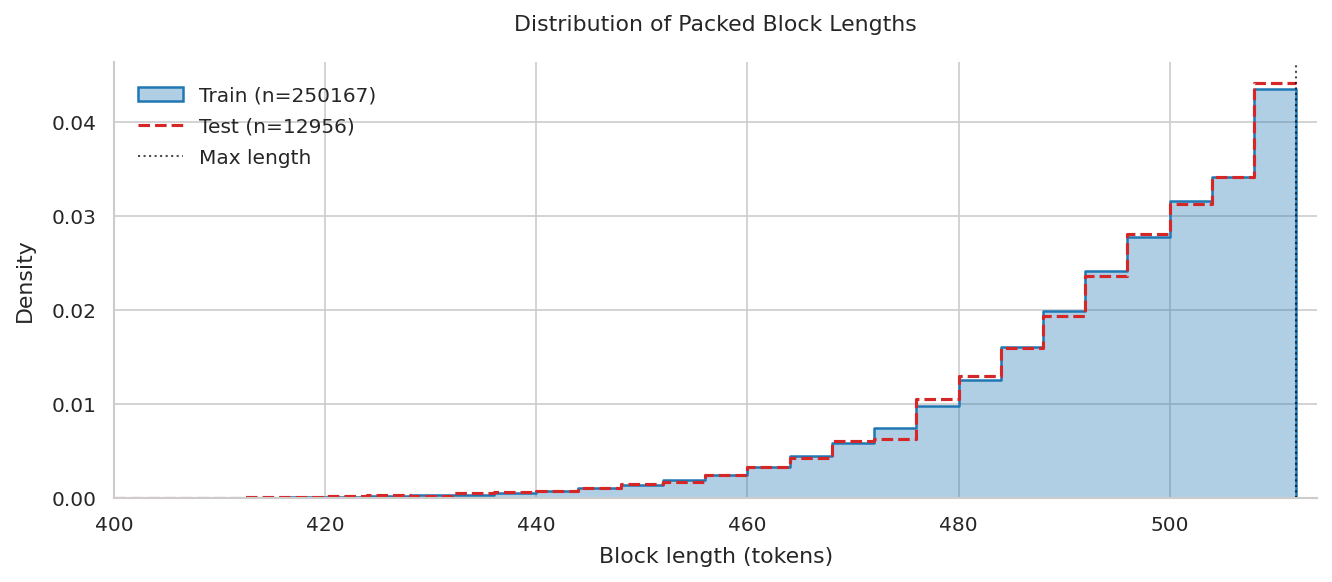

Hist exists: True
Saved to: runs/20251228-175653/pack_main/packing_blocklen_hist.png


In [21]:
PACK_DIR = make_run_dir("pack")
hist_path = PACK_DIR / "packing_blocklen_hist.png"

plot_block_length_hist(
    train_blocks, test_blocks,
    max_len=cfg.max_len,
    save_path=str(hist_path),
)

print("Hist exists:", hist_path.exists())
print("Saved to:", hist_path)

In [22]:
from datasets import Dataset as HFDataset

lm_train: HFDataset = Dataset.from_dict({"input_ids": train_blocks})
lm_test: HFDataset = Dataset.from_dict({"input_ids": test_blocks})

def add_attention_mask(batch):
    return {"attention_mask": [[1]*len(ids) for ids in batch["input_ids"]]}

lm_train = lm_train.map(add_attention_mask, batched=True)
lm_test = lm_test.map(add_attention_mask, batched=True)

lm_train.save_to_disk("lm_train_packed")
lm_test.save_to_disk("lm_test_packed")

print("Datasets created and saved to disk.")

Map:   0%|          | 0/250272 [00:00<?, ? examples/s]

Map:   0%|          | 0/12963 [00:00<?, ? examples/s]

Saving the dataset (0/2 shards):   0%|          | 0/250272 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/12963 [00:00<?, ? examples/s]

Datasets created and saved to disk.


In [23]:
lm_train = load_from_disk("lm_train_packed")
lm_test  = load_from_disk("lm_test_packed")

if isinstance(lm_train, DatasetDict):
    lm_train = lm_train["train"]
if isinstance(lm_test, DatasetDict):
    lm_test = lm_test["test"]

assert isinstance(lm_train, HFDataset)
assert isinstance(lm_test, HFDataset)

lm_test = lm_test.with_format("torch")

print(f"Training dataset: {len(lm_train)} examples")
print(f"Test dataset: {len(lm_test)} examples")

Training dataset: 250272 examples
Test dataset: 12963 examples


In [24]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=cfg.mlm_prob,
)

## Training Infrastructure

We standardize training configuration through a single `make_train_args` function with mode-specific overrides.
This ensures consistent hyperparameter handling across experiments while allowing controlled variation where needed.

Three execution modes are defined:

* **Smoke**: minimal-step run for pipeline validation
* **Sweep**: bounded-budget runs for optimizer and learning rate comparison
* **Final**: full training run with checkpointing and best-model selection

All modes share the same data pipeline, model initialization, and logging structure.
Only execution-specific parameters (e.g. `max_steps`, evaluation frequency, checkpointing) differ between modes.

In [25]:
class TimingCallback(TrainerCallback):
    def __init__(self):
        self.train_start = None
        self.step_start = None
        self.step_times = []

    def on_train_begin(self, args, state, control, **kwargs):
        self.train_start = time.time()

    def on_step_begin(self, args, state, control, **kwargs):
        self.step_start = time.time()

    def on_step_end(self, args, state, control, **kwargs):
        if self.step_start is not None:
            self.step_times.append(time.time() - self.step_start)

    def summary(self):
      if not self.step_times:
          return {
              "train_total_time_sec": None,
              "avg_sec_per_step": None,
              "n_steps_timed": 0,
          }

      total = sum(self.step_times)
      avg = total / len(self.step_times)
      return {
          "train_total_time_sec": total,
          "avg_sec_per_step": avg,
          "n_steps_timed": len(self.step_times),
      }

## Training Modes

Three execution modes are defined to structure experiments:

- **Smoke**: Short run to validate the training pipeline
- **Sweep**: Fixed-budget runs for hyperparameter comparison
- **Final**: Full training with checkpointing and best-model selection

All modes share the same data pipeline and model initialization.
Only training duration and logging behavior differ.

In [34]:
MODE_OVERRIDES = {
    "smoke": {
        "max_steps": 50,
        "eval_strategy": "steps",
        "eval_steps": 50,
        "save_strategy": "no",
        "load_best_model_at_end": False,
        "logging_steps": 20,
    },
    "final": {
        "eval_strategy": "steps",
        "eval_steps": 500,
        "save_strategy": "steps",
        "save_steps": 500,
        "save_total_limit": 3,
        "load_best_model_at_end": True,
        "metric_for_best_model": "eval_loss",
        "logging_steps": 50,
    },
    "sweep": {
        "max_steps": 300,
        "eval_strategy": "steps",
        "eval_steps": 100,
        "save_strategy": "no",
        "load_best_model_at_end": False,
        "logging_steps": 50,
    },
}


def make_train_args(cfg, out_dir: Path):
    base = dict(
        output_dir=str(out_dir),
        overwrite_output_dir=True,

        seed=cfg.seed,

        per_device_train_batch_size=cfg.train_bs,
        per_device_eval_batch_size=cfg.eval_bs,
        gradient_accumulation_steps=cfg.grad_accum,

        learning_rate=cfg.lr,
        weight_decay=cfg.wd,
        warmup_ratio=cfg.warmup,
        lr_scheduler_type="cosine",

        num_train_epochs=cfg.epochs,

        fp16=torch.cuda.is_available(),
        dataloader_num_workers=2,
        report_to="none",
    )

    base.update(MODE_OVERRIDES[cfg.mode])

    if cfg.max_steps is not None:
        base["max_steps"] = cfg.max_steps

    return TrainingArguments(**base)


## Smoke Training

Smoke training is a lightweight sanity check designed to validate the full training and evaluation pipeline.

It verifies that:

* data loading and collation work correctly
* forward, backward, and evaluation steps run without errors
* metrics, logging, and timing callbacks function as expected

Smoke runs are intentionally short and **not used for performance evaluation or model selection**.
Successful completion indicates the infrastructure is stable and ready for sweep and final experiments.

In [46]:
cfg.mode = "smoke"
cfg.max_steps = 50
cfg.train_subset = 1000
cfg.eval_subset = 200
cfg.save_artifacts = False

timing_cb = TimingCallback()

RUN_DIR_SMOKE, smoke_eval, trainer_smoke = run_dapt(
    stage_name="smoke_dapt",
    lm_train=lm_train,
    lm_test=lm_test,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    preprocess_logits_for_metrics=preprocess_logits_for_metrics,
    callbacks=[timing_cb],
)

dump_json(Path(RUN_DIR_SMOKE) / "timing.json", timing_cb.summary())
print("SMOKE DONE : ", RUN_DIR_SMOKE)

print(
    f"SMOKE | steps={timing_cb.summary()['n_steps_timed']} "
    f"| avg_sec/step={timing_cb.summary()['avg_sec_per_step']:.3f}"
)

[smoke_dapt] training started


Step,Training Loss,Validation Loss,Accuracy
50,1.298200,1.216276,0.726580


SMOKE DONE :  runs/20251228-175653/smoke_dapt_main
SMOKE | steps=50 | avg_sec/step=0.152


## Sweep: Optimizer & Learning Rate Selection

This sweep is a **bounded-budget experiment** designed to compare optimizers and learning rates under controlled conditions.
The goal is **configuration selection**, not final performance reporting.

To ensure fairness across runs:

* All experiments use the **same fixed training and evaluation subsets**.
* Each run is constrained to a **fixed number of optimization steps**.
* No checkpoints are saved and no model is promoted at this stage.

### Setup

* **Optimizers:** AdamW, SGD
* **Learning rates:** 2e-5, 3e-5, 5e-5
* **Training budget:** fixed `max_steps`
* **Evaluation:** periodic evaluation on a held-out subset
* **Metrics tracked:** evaluation loss, masked-token accuracy, training time per step

Each configuration is trained **from scratch** starting from the same pretrained base model.

In [47]:
cfg.mode = "sweep"
cfg.save_artifacts = False
cfg.max_steps = 300
cfg.train_subset = 4000
cfg.eval_subset = 500
cfg.save_artifacts = False

SWEEP_LRS = [2e-5, 3e-5, 5e-5]
SWEEP_OPTIMS = ["adamw", "sgd"]

SWEEP_MAX_STEPS = cfg.max_steps

SWEEP_EVAL_STEPS = 100
SWEEP_LOG_STEPS  = 50

RUN_DIR = make_run_dir("sweep")
SWEEP_DIR = Path(RUN_DIR) / "sweeps"
SWEEP_DIR.mkdir(parents=True, exist_ok=True)

train_sweep = lm_train.shuffle(seed=cfg.seed).select(
    range(min(cfg.train_subset, len(lm_train)))
)
eval_sweep = lm_test.select(
    range(min(cfg.eval_subset, len(lm_test)))
)

print("Sweep train/eval sizes:", len(train_sweep), len(eval_sweep))
print("Sweep dir:", SWEEP_DIR)


Sweep train/eval sizes: 4000 500
Sweep dir: runs/20251228-175653/sweep_main/sweeps


In [48]:
class SimpleTimingCB(TrainerCallback):
    def __init__(self):
        self.t0 = None

    def on_train_begin(self, args, state, control, **kwargs):
        self.t0 = time.time()

    def summary(self, steps: int):
        if self.t0 is None or steps <= 0:
            return {"train_total_sec": None, "sec_per_step": None}
        total = time.time() - self.t0
        return {"train_total_sec": total, "sec_per_step": total / steps}


class SweepTrainer(Trainer):
    def __init__(self, *args, optim_name="adamw", sgd_momentum=0.9, **kwargs):
        super().__init__(*args, **kwargs)
        self.optim_name = optim_name
        self.sgd_momentum = sgd_momentum

    def create_optimizer(self):
        if self.optimizer is not None:
            return self.optimizer

        decay_parameters = get_parameter_names(self.model, ALL_LAYERNORM_LAYERS)
        decay_parameters = [n for n in decay_parameters if not n.endswith("bias")]

        grouped = [
            {
                "params": [p for n, p in self.model.named_parameters()
                          if n in decay_parameters and p.requires_grad],
                "weight_decay": self.args.weight_decay,
            },
            {
                "params": [p for n, p in self.model.named_parameters()
                          if n not in decay_parameters and p.requires_grad],
                "weight_decay": 0.0,
            },
        ]

        if self.optim_name == "adamw":
            self.optimizer = torch.optim.AdamW(grouped, lr=self.args.learning_rate)
        elif self.optim_name == "sgd":
            self.optimizer = torch.optim.SGD(grouped, lr=self.args.learning_rate, momentum=self.sgd_momentum)
        else:
            raise ValueError(f"Unknown optimizer: {self.optim_name}")

        return self.optimizer

In [49]:
def run_one(optim_name: str, lr: float):
    model_run = AutoModelForMaskedLM.from_pretrained(cfg.model_name).to(device)
    timing_cb = SimpleTimingCB()

    run_name = f"{optim_name}_lr{lr:g}"
    out_dir = SWEEP_DIR / run_name
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f"[SWEEP] {run_name}")

    sweep_args = TrainingArguments(
        output_dir=str(out_dir),
        overwrite_output_dir=True,
        seed=cfg.seed,

        per_device_train_batch_size=cfg.train_bs,
        per_device_eval_batch_size=cfg.eval_bs,
        gradient_accumulation_steps=cfg.grad_accum,

        learning_rate=lr,
        weight_decay=cfg.wd,
        warmup_ratio=cfg.warmup,
        lr_scheduler_type="cosine",

        max_steps=SWEEP_MAX_STEPS,

        eval_strategy="steps",
        eval_steps=SWEEP_EVAL_STEPS,
        save_strategy="no",

        fp16=torch.cuda.is_available(),
        dataloader_num_workers=4,
        report_to="none",
        logging_steps=SWEEP_LOG_STEPS,
    )

    trainer = SweepTrainer(
        model=model_run,
        args=sweep_args,
        train_dataset=train_sweep,
        eval_dataset=eval_sweep,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        preprocess_logits_for_metrics=preprocess_logits_for_metrics,
        callbacks=[timing_cb],
        optim_name=optim_name,
    )

    trainer.train()
    eval_metrics = trainer.evaluate()

    steps = trainer.state.global_step
    timing = timing_cb.summary(steps)

    row = {
        "optim": optim_name,
        "lr": float(lr),
        "steps": int(steps),
        "eval_loss": float(eval_metrics["eval_loss"]),
        "eval_accuracy": float(eval_metrics.get("eval_accuracy", float("nan"))),
        "train_total_sec": timing["train_total_sec"],
        "sec_per_step": timing["sec_per_step"],
    }

    dump_json(out_dir / "result.json", row)

    del trainer, model_run
    torch.cuda.empty_cache()

    return row

results = []
for opt in SWEEP_OPTIMS:
    for lr in SWEEP_LRS:
        results.append(run_one(opt, lr))

dump_json(SWEEP_DIR / "sweep_results.json", results)
print("Saved sweep_results.json")

[SWEEP] adamw_lr2e-05


Step,Training Loss,Validation Loss,Accuracy
100,1.290600,1.184859,0.731805
200,1.268200,1.176041,0.733181
300,1.245500,1.147439,0.737471


[SWEEP] adamw_lr3e-05


Step,Training Loss,Validation Loss,Accuracy
100,1.287000,1.182352,0.732458
200,1.259300,1.172211,0.734324
300,1.233300,1.141589,0.738034


[SWEEP] adamw_lr5e-05


...

[SWEEP] sgd_lr3e-05


Step,Training Loss,Validation Loss,Accuracy
100,1.349800,1.235729,0.721408
200,1.345800,1.234731,0.722089
300,1.329600,1.209781,0.725836


[SWEEP] sgd_lr5e-05


Step,Training Loss,Validation Loss,Accuracy
100,1.345000,1.231119,0.722146
200,1.339500,1.229323,0.723483
300,1.323500,1.204545,0.727583


Saved sweep_results.json


### Analysis

The sweep results are used to analyze two aspects:

1. **Optimization behavior**

   * Stability and convergence under a fixed step budget
   * Sensitivity of each optimizer to learning rate

2. **Efficiency**

   * Average training time per step
   * Trade-off between optimization quality and computational cost

The selected configuration is the one that achieves the **lowest evaluation loss** while maintaining stable training dynamics.
This configuration is then re-trained from scratch in a separate **final run** using the full training setup.

optim    lr         loss       acc      sec/step  
------------------------------------------------------------
adamw    2e-05      1.1634     0.7385 0.208
adamw    3e-05      1.1570     0.7399 0.209
adamw    5e-05      1.1510     0.7403 0.208
sgd      2e-05      1.2337     0.7253 0.207
sgd      3e-05      1.2296     0.7261 0.205
sgd      5e-05      1.2242     0.7271 0.206


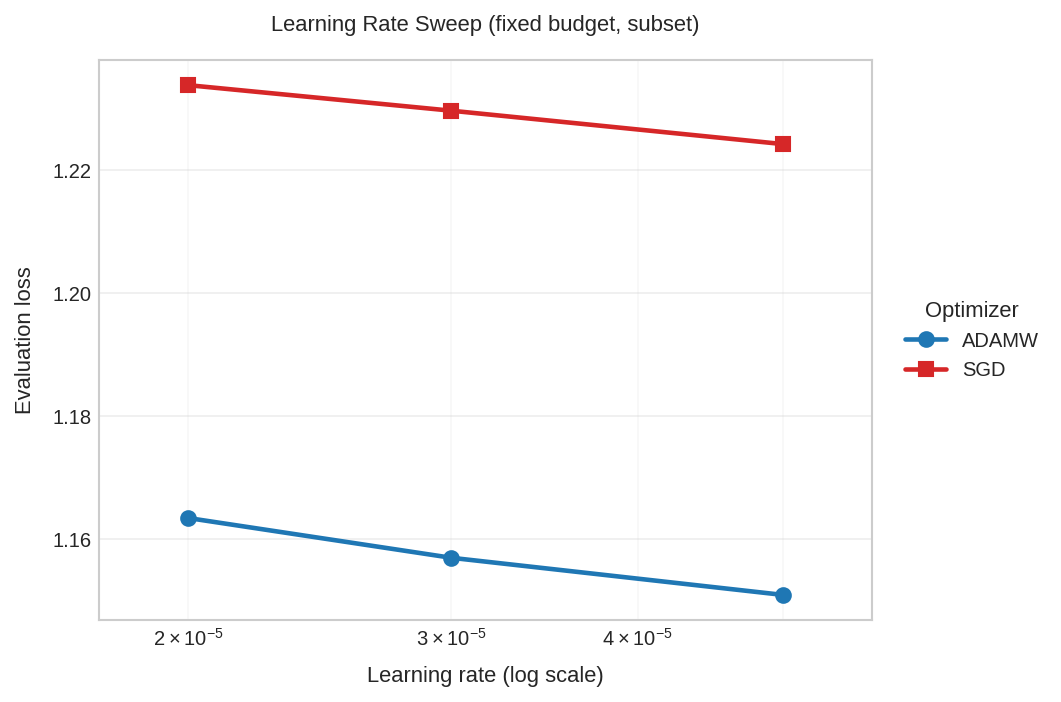

In [50]:
results = json.loads((SWEEP_DIR / "sweep_results.json").read_text())
print(f"{'optim':<8} {'lr':<10} {'loss':<10} {'acc':<8} {'sec/step':<10}")
print("-" * 60)
for r in results:
    acc = r["eval_accuracy"]
    print(
        f"{r['optim']:<8} {r['lr']:<10g} "
        f"{r['eval_loss']:<10.4f} "
        f"{acc:.4f} "
        f"{r['sec_per_step']:.3f}"
    )

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(8.5, 4.8), dpi=150)

colors = {
    "adamw": "#1f77b4",
    "sgd": "#d62728",
}

markers = {
    "adamw": "o",
    "sgd": "s",
}

for opt in SWEEP_OPTIMS:
    xs = [r["lr"] for r in results if r["optim"] == opt]
    ys = [r["eval_loss"] for r in results if r["optim"] == opt]

    ax.plot(
        xs,
        ys,
        marker=markers[opt],
        linewidth=2.2,
        markersize=7,
        label=opt.upper(),
        color=colors[opt],
    )

ax.set_xscale("log")
ax.set_xlabel("Learning rate (log scale)", labelpad=8)
ax.set_ylabel("Evaluation loss", labelpad=8)
ax.set_title("Learning Rate Sweep (fixed budget, subset)", pad=14)

ax.legend(
    title="Optimizer",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)


ax.margins(x=0.15)
ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig(SWEEP_DIR / "lr_sweep_eval_loss_clean.png", bbox_inches="tight")
plt.show()

**Analysis.**  
This sweep compares optimizers and learning rates under a fixed training budget on a small data subset.  
While absolute loss values are not representative of final model performance, relative trends are informative.

AdamW consistently outperforms SGD across all tested learning rates, indicating more efficient optimization for this task.  
For AdamW, increasing the learning rate from 2e-5 to 5e-5 leads to a monotonic decrease in evaluation loss, suggesting that the model remains in a stable learning regime within this range.

These results are used to eliminate suboptimal configurations and narrow the search space for the final full-data training run.

In [51]:
import gc
gc.collect()
torch.cuda.empty_cache()

## Final Training (DAPT)

This stage runs the **final domain-adaptive pretraining** using the full dataset and the hyperparameters chosen after the sweep experiments.

The model is initialized **from the original pretrained weights**, not from any sweep run.

### Configuration
- Model: dbmdz/bert-base-turkish-cased  
- Objective: Masked Language Modeling  
- Dataset: full training and evaluation sets  
- Optimizer: AdamW  
- Learning rate: selected from sweep  
- Scheduler: cosine with warmup  
- Epochs: 3  
- Mixed precision: enabled  

This run produces the **final DAPT checkpoint** used for downstream tasks.

In [35]:
cfg.mode = "final"
cfg.save_artifacts = True

cfg.train_subset = None
cfg.eval_subset  = None

cfg.lr = 5e-5
cfg.wd = 0.01
cfg.warmup = 0.1
cfg.optim = "adamw"

cfg.epochs = 3
cfg.max_steps = None
cfg.train_bs = 16
cfg.eval_bs = 4
cfg.grad_accum = 2

RUN_DIR_FINAL, final_eval, trainer_final = run_dapt(
    stage_name="final_dapt",
    lm_train=lm_train,
    lm_test=lm_test,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    preprocess_logits_for_metrics=preprocess_logits_for_metrics,
    callbacks=[TimingCallback()],
)

[final_dapt] training started


Step,Training Loss,Validation Loss,Accuracy
500,1.269800,1.183507,0.731999
1000,1.237500,1.153206,0.737001
1500,1.210200,1.129130,0.741418
2000,1.193600,1.121869,0.742773
2500,1.190600,1.110995,0.745190
3000,1.179900,1.105333,0.746388
3500,1.189800,1.090376,0.748683
4000,1.171100,1.081596,0.750276
4500,1.149600,1.075808,0.751145
5000,1.155800,1.071196,0.752231


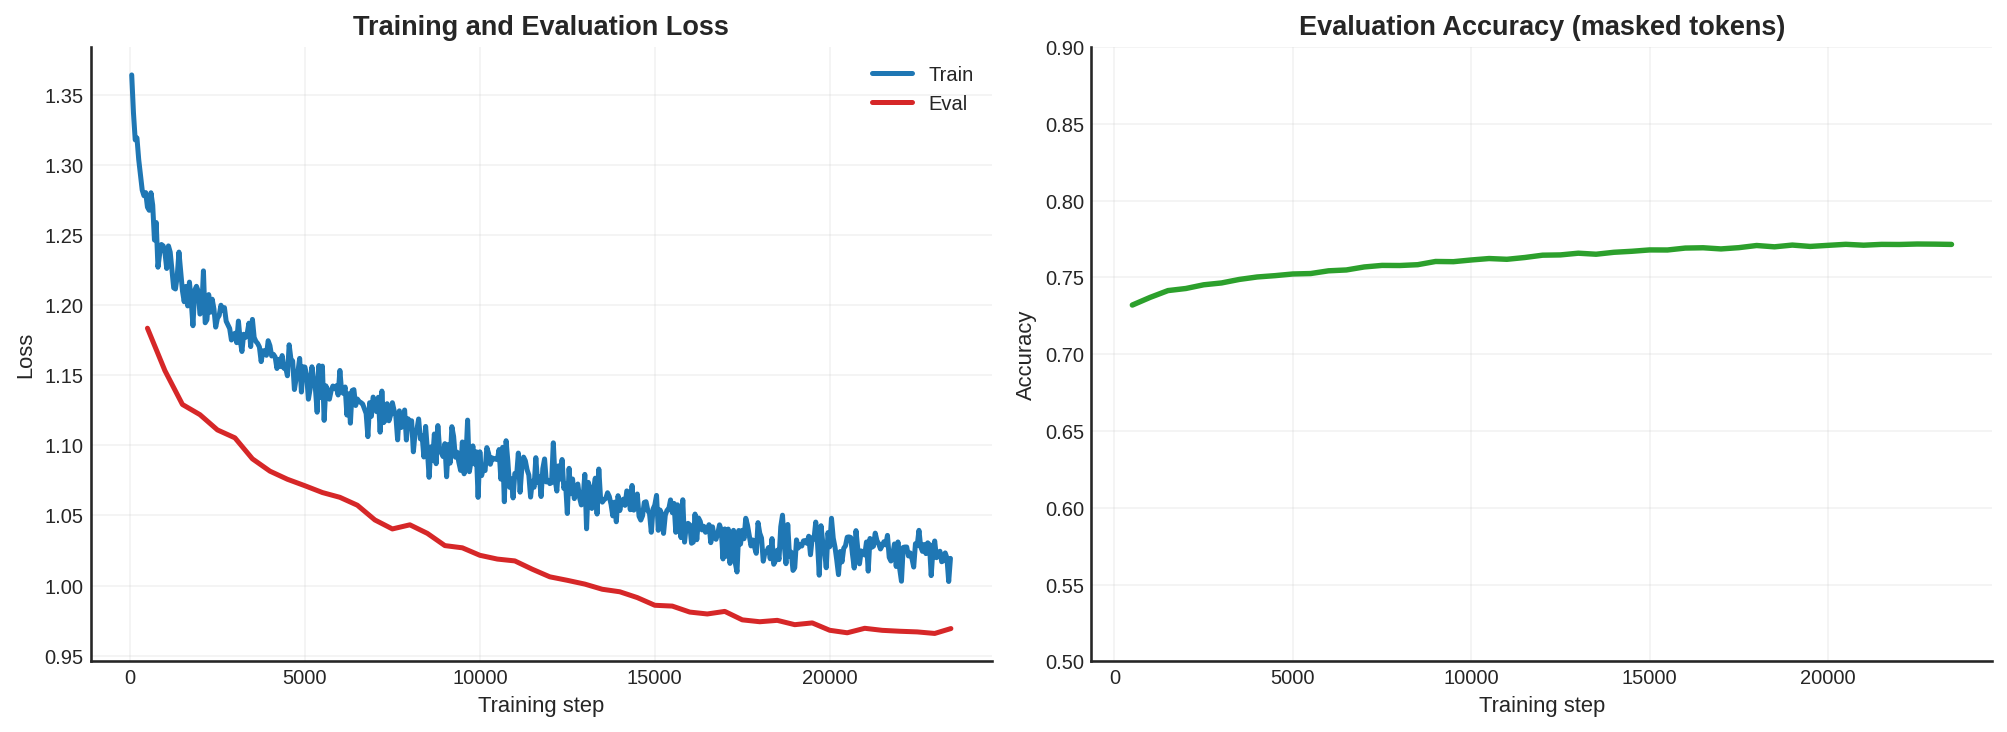

In [36]:
def plot_training_history(history, run_dir: Path):
    train_steps = [x["step"] for x in history if "loss" in x and "eval_loss" not in x]
    train_loss  = [x["loss"] for x in history if "loss" in x and "eval_loss" not in x]

    eval_steps = [x["step"] for x in history if "eval_loss" in x]
    eval_loss  = [x["eval_loss"] for x in history if "eval_loss" in x]
    eval_acc   = [x.get("eval_accuracy") for x in history if "eval_loss" in x]

    plt.style.use("seaborn-v0_8-white")
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5), dpi=150)

    # --- Loss ---
    ax = axes[0]
    ax.plot(train_steps, train_loss, label="Train", lw=2.4, color="#1f77b4")
    ax.plot(eval_steps, eval_loss,  label="Eval",  lw=2.4, color="#d62728")
    ax.set_title("Training and Evaluation Loss", fontsize=13, weight="bold")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Loss")
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)

    # --- Accuracy ---
    ax = axes[1]
    if any(v is not None for v in eval_acc):
        ax.plot(eval_steps, eval_acc, lw=2.6, color="#2ca02c")
        ax.set_ylim(0.5, 0.9)
    ax.set_title("Evaluation Accuracy (masked tokens)", fontsize=13, weight="bold")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Accuracy")
    ax.grid(alpha=0.25)

    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    out_path = run_dir / "training_history.png"
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()

history = json.loads((RUN_DIR_FINAL / "history.json").read_text())
plot_training_history(history, RUN_DIR_FINAL)


### Results
- Training and evaluation loss decrease smoothly.
- Evaluation accuracy increases steadily during training.
- No instability or divergence is observed.

In [37]:
def summarize_final_run(trainer, timing_cb, run_dir: Path):
    history = trainer.state.log_history

    last_eval = next(
        x for x in reversed(history) if "eval_loss" in x
    )

    summary = {
        "global_step": trainer.state.global_step,
        "train_steps": len([x for x in history if "loss" in x]),
        "final_eval_loss": last_eval["eval_loss"],
        "final_eval_accuracy": last_eval.get("eval_accuracy"),
        "avg_sec_per_step": timing_cb.summary().get("avg_sec_per_step"),
        "train_total_sec": timing_cb.summary().get("train_total_time_sec"),
    }

    dump_json(run_dir / "final_training_summary.json", summary)
    return summary

summary = summarize_final_run(trainer_final, timing_cb, RUN_DIR_FINAL)
print(json.dumps(summary, indent=2))

{
  "global_step": 23463,
  "train_steps": 469,
  "final_eval_loss": 0.9693596959114075,
  "final_eval_accuracy": 0.7714779544205227,
  "avg_sec_per_step": 0.29794904920789933,
  "train_total_sec": 2.6815414428710938
}


In [38]:
final_test_metrics = eval_mlm_on_dataset(
    model_path=str(RUN_DIR_FINAL / "final_model"),
    dataset=lm_test,
    tokenizer=tokenizer,
    mlm_prob=cfg.mlm_prob,
    batch_size=cfg.eval_bs,
    topk=5,
)

dump_json(
    RUN_DIR_FINAL / "final_test_metrics.json",
    final_test_metrics
)

print("\n--- Final Evaluation ---")
for k, v in final_test_metrics.items():
  print(f"{k:>15}: {v}")

Eval MLM (runs/20251228-175653/final_dapt_main/final_model):   0%|          | 0/3241 [00:00<?, ?it/s]


--- Final Evaluation ---
       avg_loss: 0.9661770133334374
     perplexity: 2.627878885395644
       top1_acc: 0.7717451800033198
       top5_acc: 0.9024576531381647
  masked_tokens: 921733
          steps: 3241


### Baseline MLM Evaluation (Test Set)

The pretrained `dbmdz/bert-base-turkish-cased` model is evaluated on the downstream
test split using a masked language modeling (MLM) objective.

This baseline serves as a reference point for:
- Test-set performance comparison after domain-adaptive pretraining (DAPT)
- Measuring gains on domain-specific data
- Detecting potential regressions in generalization

All metrics are computed on masked tokens only and include loss, perplexity,
Top-1 accuracy, and Top-5 accuracy.

In [39]:
BASELINE_EVAL_DIR = Path("eval") / "baseline"
BASELINE_EVAL_DIR.mkdir(parents=True, exist_ok=True)

baseline_metrics = eval_mlm_on_dataset(
    model_path=cfg.model_name,
    dataset=lm_test,
    tokenizer=tokenizer,
    mlm_prob=cfg.mlm_prob,
    batch_size=cfg.eval_bs,
    topk=5,
)

dump_json(BASELINE_EVAL_DIR / "baseline_test_metrics.json", baseline_metrics)

print("\n--- Baseline (Test Set) ---")
for k, v in baseline_metrics.items():
    print(f"{k:>15}: {v}")

Eval MLM (dbmdz/bert-base-turkish-cased):   0%|          | 0/3241 [00:00<?, ?it/s]


--- Baseline (Test Set) ---
       avg_loss: 1.2642156293420872
     perplexity: 3.540314727765058
       top1_acc: 0.7166998550988711
       top5_acc: 0.8662853250731013
  masked_tokens: 922008
          steps: 3241


## Catastrophic Forgetting Evaluation

This section evaluates whether domain-adaptive pretraining (DAPT) causes **catastrophic forgetting**, i.e., degradation of the model’s general language modeling ability after adapting to a domain-specific corpus.

### Evaluation Protocol
- **Task:** Masked Language Modeling (MLM)  
- **Out-of-domain dataset:** Turkish Wikipedia  
- **Evaluation split:** 10,000 documents  
- **Masking probability:** Same as training (`mlm_prob = 0.15`)  
- **Metrics:**  
  - Average MLM loss  
  - Perplexity (PPL)

### Compared Models
- **Base model:** `dbmdz/bert-base-turkish-cased`  
- **DAPT model:** Final domain-adapted checkpoint  

Both models are evaluated under identical conditions, without additional fine-tuning, to isolate the effect of domain-adaptive pretraining on general-language performance.

In [40]:
print("Loading Turkish Wikipedia...")

wiki_ds = load_dataset(
    "wikimedia/wikipedia",
    "20231101.tr",
    split="train[:10000]"
)

def tokenize_fn(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=cfg.max_len,
        padding="max_length"
    )

wiki_tok = wiki_ds.map(
    tokenize_fn,
    batched=True,
    remove_columns=["text", "id", "url", "title"]
)
wiki_tok.set_format("torch")

wiki_loader = DataLoader(
    wiki_tok,
    batch_size=cfg.eval_bs,
    collate_fn=DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm_probability=cfg.mlm_prob
    )
)

print(f"Wikipedia eval documents: {len(wiki_tok)}")

Loading Turkish Wikipedia...


README.md: 0.00B [00:00, ?B/s]

20231101.tr/train-00000-of-00002.parquet:   0%|          | 0.00/340M [00:00<?, ?B/s]

20231101.tr/train-00001-of-00002.parquet:   0%|          | 0.00/213M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/534988 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Wikipedia eval documents: 10000


In [41]:
wiki_base_metrics = eval_mlm_on_dataset(
    model_path=cfg.model_name,
    dataset=wiki_tok,
    tokenizer=tokenizer,
    mlm_prob=cfg.mlm_prob,
    batch_size=cfg.eval_bs,
    topk=5,
)

wiki_dapt_metrics = eval_mlm_on_dataset(
    model_path=str(RUN_DIR_FINAL / "final_model"),
    dataset=wiki_tok,
    tokenizer=tokenizer,
    mlm_prob=cfg.mlm_prob,
    batch_size=cfg.eval_bs,
    topk=5,
)

wiki_results = {
    "base": wiki_base_metrics,
    "dapt": wiki_dapt_metrics,
}

dump_json(
    RUN_DIR_FINAL / "wiki_mlm_results.json",
    wiki_results
)

print("\n--- Wikipedia MLM Results ---")

for name, metrics in wiki_results.items():
    print(f"\n[{name.upper()} MODEL]")
    print(f"{'Loss':>18}: {metrics['avg_loss']:.4f}")
    print(f"{'Perplexity':>18}: {metrics['perplexity']:.2f}")
    print(f"{'Top-1 Accuracy':>18}: {metrics['top1_acc']*100:.2f}%")
    print(f"{'Top-5 Accuracy':>18}: {metrics['top5_acc']*100:.2f}%")
    print(f"{'Masked tokens':>18}: {metrics['masked_tokens']:,}")

Eval MLM (dbmdz/bert-base-turkish-cased):   0%|          | 0/2500 [00:00<?, ?it/s]

Eval MLM (runs/20251228-175653/final_dapt_main/final_model):   0%|          | 0/2500 [00:00<?, ?it/s]


--- Wikipedia MLM Results ---

[BASE MODEL]
              Loss: 1.5729
        Perplexity: 4.82
    Top-1 Accuracy: 68.92%
    Top-5 Accuracy: 84.54%
     Masked tokens: 506,821

[DAPT MODEL]
              Loss: 1.7225
        Perplexity: 5.60
    Top-1 Accuracy: 67.20%
    Top-5 Accuracy: 83.23%
     Masked tokens: 506,073


In [42]:
def print_full_comparison(
    base_test, dapt_test,
    base_wiki, dapt_wiki,
):
    print("\n" + "=" * 96)
    print("BASE vs DAPT — TEST & WIKIPEDIA (MLM Evaluation)")
    print("=" * 96)
    print(
        f"{'Dataset':<12} | {'Metric':<18} | "
        f"{'Base':<20} | {'DAPT':<20}"
    )
    print("-" * 96)

    rows = [
        ("Loss", "avg_loss", False),
        ("Perplexity", "perplexity", False),
        ("Top-1 Accuracy", "top1_acc", True),
        ("Top-5 Accuracy", "top5_acc", True),
    ]

    for dataset, base_m, dapt_m in [
        ("Test", base_test, dapt_test),
        ("Wiki", base_wiki, dapt_wiki),
    ]:
        for name, key, is_acc in rows:
            b = base_m[key]
            d = dapt_m[key]

            if is_acc:
                b = f"{b*100:.2f}%"
                d = f"{d*100:.2f}%"
            else:
                b = f"{b:.4f}"
                d = f"{d:.4f}"

            print(
                f"{dataset:<12} | {name:<18} | "
                f"{b:<20} | {d:<20}"
            )
        print("-" * 96)

    print("=" * 96)

In [43]:
print_full_comparison(
    base_test=baseline_metrics,
    dapt_test=final_test_metrics,
    base_wiki=wiki_base_metrics,
    dapt_wiki=wiki_dapt_metrics,
)


BASE vs DAPT — TEST & WIKIPEDIA (MLM Evaluation)
Dataset      | Metric             | Base                 | DAPT                
------------------------------------------------------------------------------------------------
Test         | Loss               | 1.2642               | 0.9662              
Test         | Perplexity         | 3.5403               | 2.6279              
Test         | Top-1 Accuracy     | 71.67%               | 77.17%              
Test         | Top-5 Accuracy     | 86.63%               | 90.25%              
------------------------------------------------------------------------------------------------
Wiki         | Loss               | 1.5729               | 1.7225              
Wiki         | Perplexity         | 4.8204               | 5.5986              
Wiki         | Top-1 Accuracy     | 68.92%               | 67.20%              
Wiki         | Top-5 Accuracy     | 84.54%               | 83.23%              
------------------------------------

In [44]:
def plot_domain_vs_forgetting(
    base_test, dapt_test,
    base_wiki, dapt_wiki,
):
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), dpi=150)

    datasets = [
        ("Test (Domain)", base_test, dapt_test),
        ("Wikipedia (General)", base_wiki, dapt_wiki),
    ]

    metrics = [
        ("avg_loss", "MLM Loss", False),
        ("top1_acc", "Top-1 Accuracy (%)", True),
    ]

    colors = ["#1f77b4", "#d62728"]

    for row, (ds_name, base_m, dapt_m) in enumerate(datasets):
        for col, (key, label, is_acc) in enumerate(metrics):
            ax = axes[row, col]

            base_val = base_m[key]
            dapt_val = dapt_m[key]

            if is_acc:
                base_val *= 100
                dapt_val *= 100

            ax.bar(
                ["Base", "DAPT"],
                [base_val, dapt_val],
                color=colors,
                width=0.6,
            )

            ax.set_title(
                f"{ds_name} — {label}",
                fontsize=11,
                weight="bold",
            )

            ax.grid(axis="y", alpha=0.3)

            for i, v in enumerate([base_val, dapt_val]):
                ax.text(
                    i, v,
                    f"{v:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )

    plt.suptitle(
        "Domain Gain vs Catastrophic Forgetting",
        fontsize=14,
        weight="bold",
        y=0.98,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

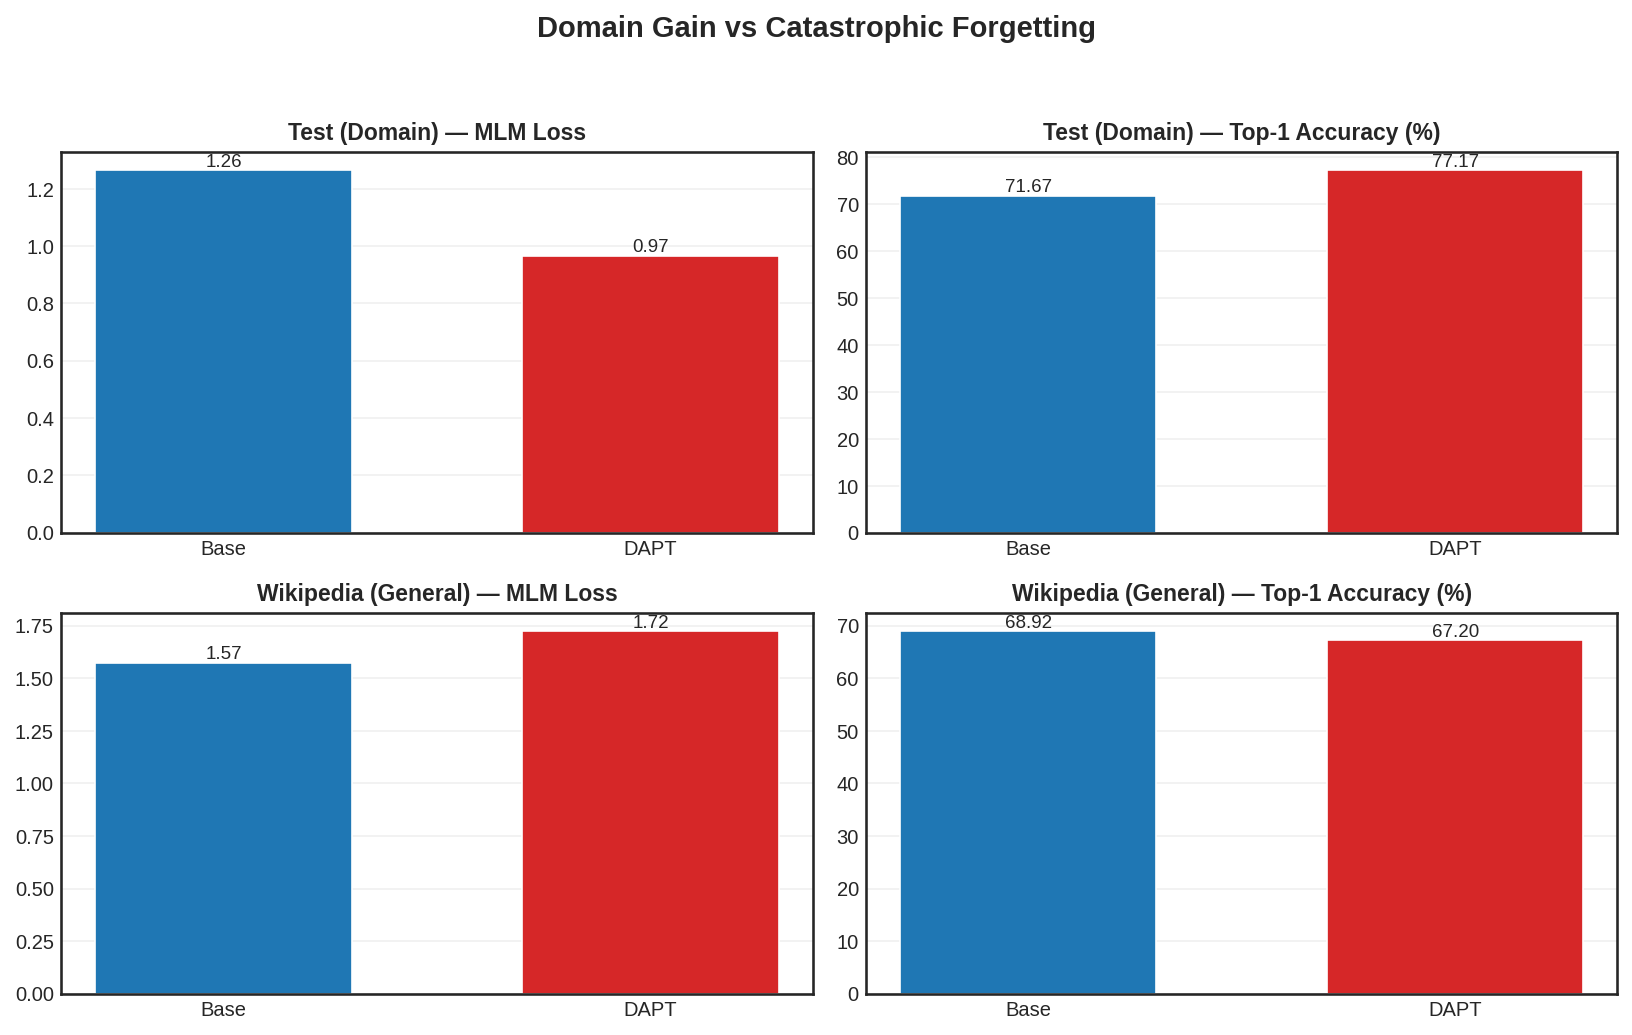

In [45]:
plot_domain_vs_forgetting(
    base_test=baseline_metrics,
    dapt_test=final_test_metrics,
    base_wiki=wiki_base_metrics,
    dapt_wiki=wiki_dapt_metrics,
)